Title: PSL_mean_and_anomaly.ipynb

Purpose: Calculate a model mean and the psl anomaly data

Author: Onno Nennecke on 02.06.2025 Modified: 20.07.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [2]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
# import cftime
import re

# Importing functions
import Functions.grid_func as grid_func

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [3]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

### Read data

In [4]:
# Read the dataframe from the csv file
used_runs = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs.csv')


# Add one row with ERA5 using pd.concat
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = pd.concat([used_runs, era5_row], ignore_index=True)

# Change the ref column to 1 for the first instance of each model
# used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

ESMs = used_runs['ESM'].unique()

In [5]:
base_path = '/climca/people/onennecke/not_debiased_data/'

# Show all files in the base path
files = os.listdir(base_path)
psl_files = [fn for fn in files if '_psl' in os.path.basename(fn)]
len(psl_files)

# Combine the base path with the file names
psl_files = [os.path.join(base_path, fn) for fn in psl_files]

psl_ds = xr.open_dataset(psl_files[20])  # Open the first file to check the structure
psl_ds.load()

# Open the files using xarray
# psl_ds = xr.open_mfdataset(psl_files, combine='by_coords')

<xarray.Dataset> Size: 29MB
Dimensions:   (time: 3650, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U9 36B 'EC-Earth3'
    run       <U10 40B 'r125i1p1f1'
    ESM_run   <U20 80B 'EC-Earth3_r125i1p1f1'
Data variables:
    psl       (time, lat, lon) float32 29MB 1.022e+05 1.022e+05 ... 1.03e+05
Attributes:
    regrid_method:  bilinear

In [ ]:
# Calculate the mean over the ESM dimension and save it to a new file
for esm in ESMs:
    ds_list = []
    esm_files = [fn for fn in psl_files if esm in os.path.basename(fn)]
    print(f'Processing {esm} with {len(esm_files)} files...')
    for fn in esm_files:
        print(f'Opening file: {fn}')
        ds = xr.open_dataset(fn)
        esm_run = ds.ESM_run.values
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        
        # Calculate the mean over the time dimension
        mean_ts_ds = ds.mean(dim='time', keep_attrs=True)
        
        ts_output = mean_ts_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)

    psl_esm_ds = xr.concat(ds_list, dim="ESM_run")

    psl_esm_mean = psl_esm_ds.mean(dim='ESM_run')

    # If there is a run coordinate, remove it
    if 'run' in psl_esm_mean.coords:
        psl_esm_mean = psl_esm_mean.reset_coords('run', drop=True)

    psl_esm_mean = psl_esm_mean.expand_dims(ESM=[esm])
    
    # Save the mean dataset to a new file
    # output_file = (f'/climca/people/onennecke/model_output/var_means/psl_not_bc/psl_mean_{esm}.nc')
    output_file = (f'/climca/people/onennecke/model_output/var_means/psl_not_bc/winter/psl_mean_{esm}.nc')
    psl_esm_mean.to_netcdf(output_file)
    print(f'Saved mean dataset for {esm} to {output_file}')


Processing ACCESS-CM2 with 3 files...
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r5i1p1f1_psl.nc
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r4i1p1f1_psl.nc
Opening file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r1i1p1f1_psl.nc
Saved mean dataset for ACCESS-CM2 to /climca/people/onennecke/model_output/var_means/psl_not_bc_new/winter/psl_mean_ACCESS-CM2.nc
Processing BCC-CSM2-MR with 1 files...
Opening file: /climca/people/onennecke/not_debiased_data/BCC-CSM2-MR_r1i1p1f1_psl.nc
Saved mean dataset for BCC-CSM2-MR to /climca/people/onennecke/model_output/var_means/psl_not_bc_new/winter/psl_mean_BCC-CSM2-MR.nc
Processing CESM2 with 3 files...
Opening file: /climca/people/onennecke/not_debiased_data/CESM2_r10i1p1f1_psl.nc
Opening file: /climca/people/onennecke/not_debiased_data/CESM2_r4i1p1f1_psl.nc
Opening file: /climca/people/onennecke/not_debiased_data/CESM2_r11i1p1f1_psl.nc
Saved mean dataset for CESM2 to /climca/people/onenn

---

In [ ]:
path = '/climca/people/onennecke/model_output/var_means/psl_not_bc/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))

files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')

ts_datasets.load()

<xarray.Dataset> Size: 89kB
Dimensions:   (ESM: 11, lat: 40, lon: 50)
Coordinates:
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
Data variables:
    psl       (ESM, lat, lon) float32 88kB 1.02e+05 1.02e+05 ... 1.012e+05

In [ ]:
path = '/climca/people/onennecke/model_output/var_means/psl_not_bc/winter/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))

files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')

ts_datasets.load()

<xarray.Dataset> Size: 89kB
Dimensions:   (ESM: 11, lat: 40, lon: 50)
Coordinates:
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
Data variables:
    psl       (ESM, lat, lon) float32 88kB 1.021e+05 1.021e+05 ... 1.011e+05

In [ ]:
# Check again with the old files
path = '/climca/people/onennecke/model_output/var_means/psl_not_bc_old/'
files = sorted(glob.glob(os.path.join(path, '*.nc')))

files
ts_datasets_old = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')
# Remove the 'run' coordinate
ts_datasets_old = ts_datasets_old.reset_coords('run', drop=True)
ts_datasets_old.load()
# ts_datasets['psl'].isel(ESM = 0, lat = 0).values

<xarray.Dataset> Size: 186kB
Dimensions:   (lat: 40, lon: 50, ESM: 23)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * ESM       (ESM) <U13 1kB 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
Data variables:
    psl       (lat, lon, ESM) float32 184kB 1.021e+05 1.022e+05 ... 1.008e+05
Attributes:
    regrid_method:  bilinear

---

In [9]:
# Add one combinded dataset for all ESMs as a new ESM variable called 'combined'
ts_combined = ts_datasets.mean(dim='ESM', keep_attrs=True)
ts_combined = ts_combined.assign_coords(ESM='Combined')
# Combine the datasets
ts_datasets = xr.concat([ts_datasets, ts_combined], dim='ESM')
ts_datasets.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'

In [10]:
encoding = {}

all_vars = {**ts_datasets.data_vars, **ts_datasets.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'ESM': {'dtype': 'U13'}, 'gridtype': {'dtype': 'U6'}}

In [ ]:
# Save the combined dataset
ts_datasets.to_netcdf('/climca/people/onennecke/model_output/var_means/psl_not_bc/psl_mean_combined.nc', encoding=encoding)

In [ ]:
# Open the combined dataset
ts_combined = xr.open_dataset('/climca/people/onennecke/model_output/var_means/psl_not_bc/psl_mean_combined.nc')
ts_combined.load()

<xarray.Dataset> Size: 97kB
Dimensions:   (ESM: 12, lat: 40, lon: 50)
Coordinates:
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
Data variables:
    psl       (ESM, lat, lon) float32 96kB 1.021e+05 1.021e+05 ... 1.008e+05

#### Plot

/tmp/ipykernel_2667101/3615381052.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title


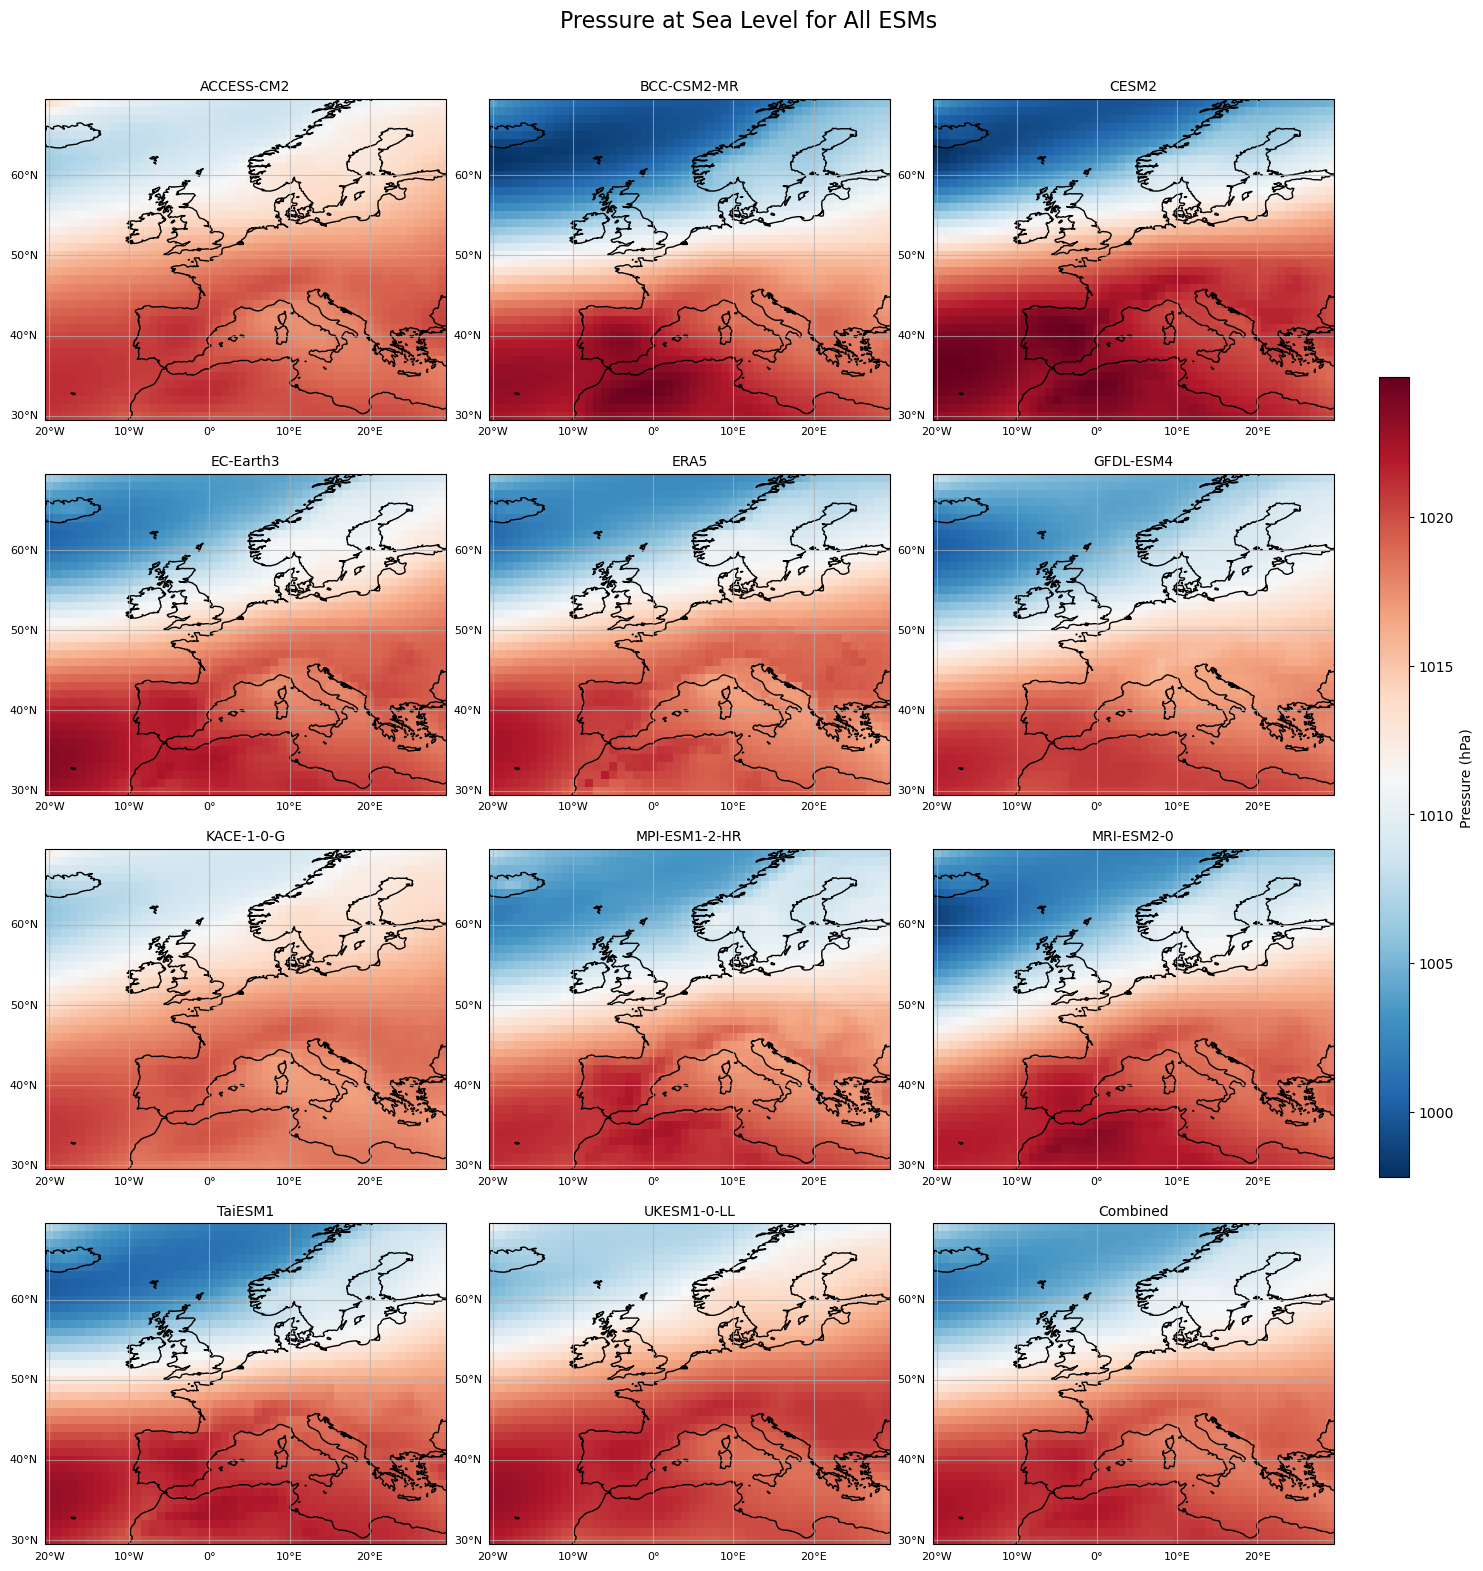

In [14]:
# Define vmin and vmax once
vmin = ts_combined['psl'].where(ts_combined['psl'] > 0).min() / 100
vmax = ts_combined['psl'].max() / 100

# Get ESM list and determine subplot layout
esm_list = ts_combined.ESM.values
n = len(esm_list)

# Choose rows/cols for subplot grid (auto-fit)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceil division

# Create a big figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes for easier indexing (handles both 1D/2D cases)
axes = axes.flatten()

for i, ESM in enumerate(esm_list):
    # print('ESM:', ESM)
    ds = ts_combined.sel(ESM=ESM)
    
    # Shift longitudes
    new_lon = ((ds['psl'].lon + 180) % 360) - 180
    da2 = ds['psl'].assign_coords(lon=new_lon) / 100

    # Plot on respective axis
    ax = axes[i]
    p = da2.plot(ax=ax, transform=ccrs.PlateCarree(),
                 cmap='RdBu_r', add_colorbar=False,
                 vmin=vmin, vmax=vmax)

    ax.coastlines()
    setup_gridlines(ax, deg=10, alpha=0.7)
    ax.set_title(f'{ESM}', fontsize=10)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add one shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle('Pressure at Sea Level for All ESMs', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title
plt.show()

## Calculate Anomaly

In [10]:
xr.open_mfdataset(psl_files[0]).load()

<xarray.Dataset> Size: 29MB
Dimensions:   (time: 3650, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U9 36B 'EC-Earth3'
    run       <U10 40B 'r112i1p1f1'
    ESM_run   <U20 80B 'EC-Earth3_r112i1p1f1'
Data variables:
    psl       (time, lat, lon) float32 29MB 1.025e+05 1.024e+05 ... 1.004e+05
Attributes:
    regrid_method:  bilinear

In [13]:
for psl_fl in psl_files:
    run_time = time.time()
    nc = xr.open_mfdataset(psl_fl)
    ESM = nc.ESM.values
    run = nc.run.values
    print(f'Processing {ESM}, {run}')

    # Filter to only winter months (October to March)
    nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
    psl_anomaly = nc.copy()
    # Calculate anomaly
    psl_anomaly['psl'] = nc['psl'] - ts_combined.sel(ESM = ESM)['psl']

    ts_output = psl_anomaly.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    ts_output.load()
    ts_output.to_netcdf(f'/climca/people/onennecke/model_output/psl_anomaly/not_bc/{ESM}_{run}_psl_anomaly.nc')
    # break


Processing EC-Earth3, r112i1p1f1
Processing EC-Earth3, r110i1p1f1
Processing TaiESM1, r1i1p1f1
Processing MPI-ESM1-2-HR, r5i1p1f1
Processing MPI-ESM1-2-HR, r2i1p1f1
Processing CESM2, r10i1p1f1
Processing ERA5, hist
Processing EC-Earth3, r144i1p1f1
Processing UKESM1-0-LL, r4i1p1f2
Processing MRI-ESM2-0, r2i1p1f1
Processing KACE-1-0-G, r2i1p1f1
Processing UKESM1-0-LL, r5i1p1f2
Processing GFDL-ESM4, r1i1p1f1
Processing ACCESS-CM2, r5i1p1f1
Processing EC-Earth3, r1i1p1f1
Processing EC-Earth3, r109i1p1f1
Processing UKESM1-0-LL, r16i1p1f2
Processing MPI-ESM1-2-HR, r8i1p1f1
Processing MPI-ESM1-2-HR, r1i1p1f1
Processing EC-Earth3, r104i1p1f1
Processing EC-Earth3, r125i1p1f1
Processing EC-Earth3, r121i1p1f1
Processing UKESM1-0-LL, r15i1p1f2
Processing EC-Earth3, r149i1p1f1
Processing EC-Earth3, r113i1p1f1
Processing EC-Earth3, r132i1p1f1
Processing UKESM1-0-LL, r14i1p1f2
Processing UKESM1-0-LL, r6i1p1f2
Processing EC-Earth3, r4i1p1f1
Processing EC-Earth3, r102i1p1f1
Processing EC-Earth3, r5i1p1

In [14]:
ts_output

<xarray.Dataset> Size: 15MB
Dimensions:   (time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U9 36B 'EC-Earth3'
    run       <U10 40B 'r146i1p1f1'
    ESM_run   <U20 80B 'EC-Earth3_r146i1p1f1'
Data variables:
    psl       (time, lat, lon) float32 15MB 654.2 632.8 608.6 ... -657.1 -576.6
Attributes:
    regrid_method:  bilinear

### Load data again

In [16]:
path = '/climca/people/onennecke/model_output/psl_anomaly/not_bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 1GB
Dimensions:   (ESM_run: 100, time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
Data variables:
    psl       (ESM_run, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1820, 40, 50), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

/tmp/ipykernel_2677856/3414079843.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


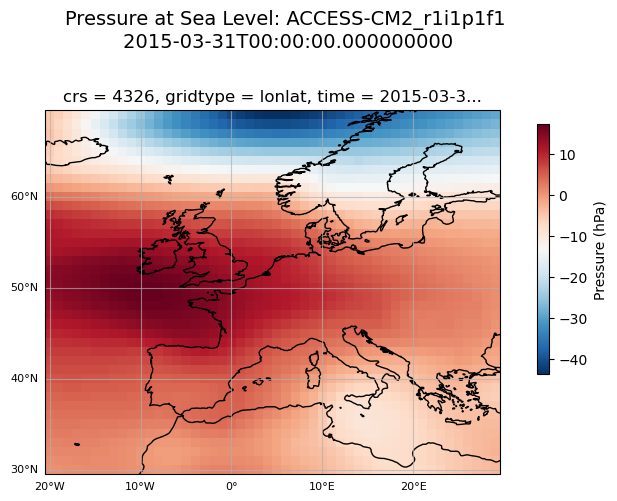

In [17]:
# Select a specific ESM run and one time step
tst = ts_datasets.sel(ESM_run='ACCESS-CM2_r1i1p1f1').isel(time=89)

# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].where(tst['psl'] > 0).min() / 100
vmin_da = tst['psl'].min() / 100

vmax_da = tst['psl'].max() / 100

# Force evaluation and extract a scalar
vmin = float(vmin_da.compute())
vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle(f'Pressure at Sea Level: ACCESS-CM2_r1i1p1f1\n {tst.time.values}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()
